In [1]:
#Task 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('q2_customers.csv')
print("=" * 50)
print(f"Dataset Shape: {df.shape}")
print("=" * 50)
print("\nData Types & Missing Values:")
info = pd.DataFrame({
    'dtype'  : df.dtypes,
    'missing': df.isnull().sum()
})
print(info)
print("\nDescriptive Statistics:")
df.describe().round(2)

Dataset Shape: (500, 6)

Data Types & Missing Values:
                          dtype  missing
age                       int64        0
annual_spend              int64        0
visits_per_month          int64        0
basket_size               int64        0
days_since_last_visit     int64        0
num_categories_purchased  int64        0

Descriptive Statistics:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,40.45,48856.95,8.41,2682.29,49.47,4.66
std,14.43,32856.80,5.32,2274.96,49.70,2.44
min,18.00,5038.00,1.00,212.00,0.00,1.00
25%,28.00,19213.25,4.00,727.75,12.00,3.00
50%,41.00,44257.00,8.00,2051.50,33.00,4.00
75%,50.00,75373.00,12.00,4223.75,61.25,6.00
max,69.00,119757.00,19.00,7981.00,179.00,9.00


In [2]:
features = ['age','annual_spend','visits_per_month',
          'basket_size', 'days_since_last_visit',
          'num_categories_purchased']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Scaled features statistics (should be mean≈0, std≈1):")
print(X_scaled_df.describe().round(3))


Scaled features statistics (should be mean≈0, std≈1):
           age  annual_spend  visits_per_month  basket_size  \
count  500.000       500.000           500.000      500.000   
mean     0.000         0.000             0.000       -0.000   
std      1.001         1.001             1.001        1.001   
min     -1.558        -1.335            -1.394       -1.087   
25%     -0.864        -0.903            -0.830       -0.860   
50%      0.038        -0.140            -0.078       -0.278   
75%      0.662         0.808             0.674        0.678   
max      1.981         2.160             1.990        2.331   

       days_since_last_visit  num_categories_purchased  
count                500.000                   500.000  
mean                  -0.000                    -0.000  
std                    1.001                     1.001  
min                   -0.996                    -1.502  
25%                   -0.755                    -0.681  
50%                   -0.332        

In [3]:
#Task 2
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    print(f"  K = {k:2d}  |  WCSS = {km.inertia_:,.2f}")

print("\nWCSS computed for K = 1 to 10.")

  K =  1  |  WCSS = 3,000.00
  K =  2  |  WCSS = 968.99
  K =  3  |  WCSS = 561.25
  K =  4  |  WCSS = 444.93
  K =  5  |  WCSS = 402.37
  K =  6  |  WCSS = 370.39
  K =  7  |  WCSS = 346.95
  K =  8  |  WCSS = 319.90
  K =  9  |  WCSS = 303.28
  K = 10  |  WCSS = 289.11

WCSS computed for K = 1 to 10.


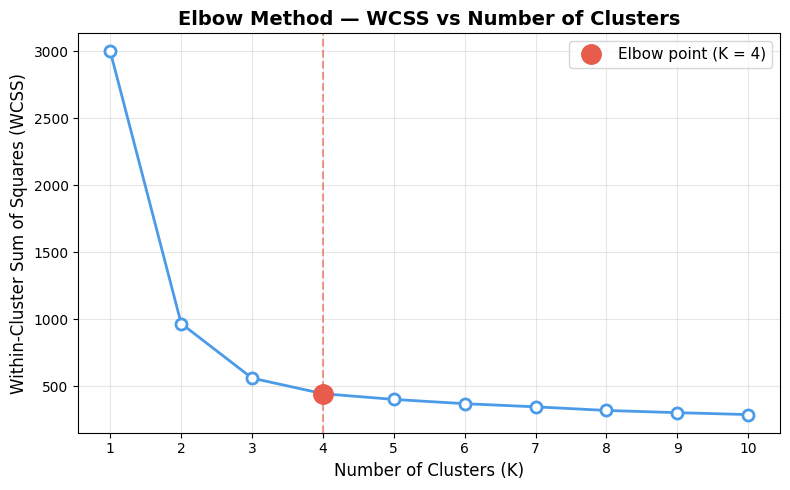

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(list(K_range), wcss, marker='o', linewidth=2,
        color='#4C9BE8', markerfacecolor='white',
        markeredgecolor='#4C9BE8', markeredgewidth=2, markersize=8)

ax.plot(4, wcss[3], 'o', markersize=14, color='#E85C4C',
        zorder=5, label='Elbow point (K = 4)')
ax.axvline(x=4, linestyle='--', color='#E85C4C', alpha=0.6)

ax.set_title('Elbow Method — WCSS vs Number of Clusters', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
ax.set_xticks(list(K_range))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_elbow.png', dpi=120)
plt.show()

In [5]:
#Task 3
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster assignment counts:")
print(df['cluster'].value_counts().sort_index().rename('count'))

Cluster assignment counts:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64


In [6]:
centroids_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=features)
centroids_original = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
).round(1)
centroids_original.index.name = 'cluster'

print("Cluster Centroids (original scale):")
print(centroids_original.to_string())

Cluster Centroids (original scale):
          age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
cluster                                                                                                    
0        24.7       14847.4              14.3        559.0                    9.1                       2.1
1        57.0       89814.1               2.5       5296.4                  148.0                       7.5
2        40.4       43340.7               8.2       2021.7                   35.2                       4.4
3        56.5       89036.2               2.6       5751.0                   65.2                       7.5


In [7]:
cluster_profile = df.groupby('cluster')[features].mean().round(1)
cluster_profile['size'] = df['cluster'].value_counts().sort_index()
print("\nFull Cluster Profile:")
print(cluster_profile.to_string())


Full Cluster Profile:
          age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased  size
cluster                                                                                                          
0        24.7       14847.4              14.3        559.0                    9.1                       2.1   170
1        57.0       89814.1               2.5       5296.4                  148.0                       7.5    80
2        40.4       43340.7               8.2       2021.7                   35.2                       4.4   165
3        56.5       89036.2               2.6       5751.0                   65.2                       7.5    85


In [8]:
#Task 4
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

print("Explained Variance Ratio:")
for i, evr in enumerate(pca.explained_variance_ratio_, 1):
    print(f"  PC{i}: {evr:.4f}  ({evr*100:.2f}%)")

total = pca.explained_variance_ratio_.sum()
print(f"\n  Total variance explained by 2 PCs: {total*100:.2f}%")

Explained Variance Ratio:
  PC1: 0.8356  (83.56%)
  PC2: 0.0557  (5.57%)

  Total variance explained by 2 PCs: 89.13%


In [9]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=['PC1', 'PC2']
).round(4)

print("Feature Loadings (PCA Components):")
print(loadings.to_string())

Feature Loadings (PCA Components):
                             PC1     PC2
age                       0.4116 -0.2594
annual_spend              0.4215 -0.0333
visits_per_month         -0.4104  0.2083
basket_size               0.4120 -0.1954
days_since_last_visit     0.3786  0.9112
num_categories_purchased  0.4140 -0.1405


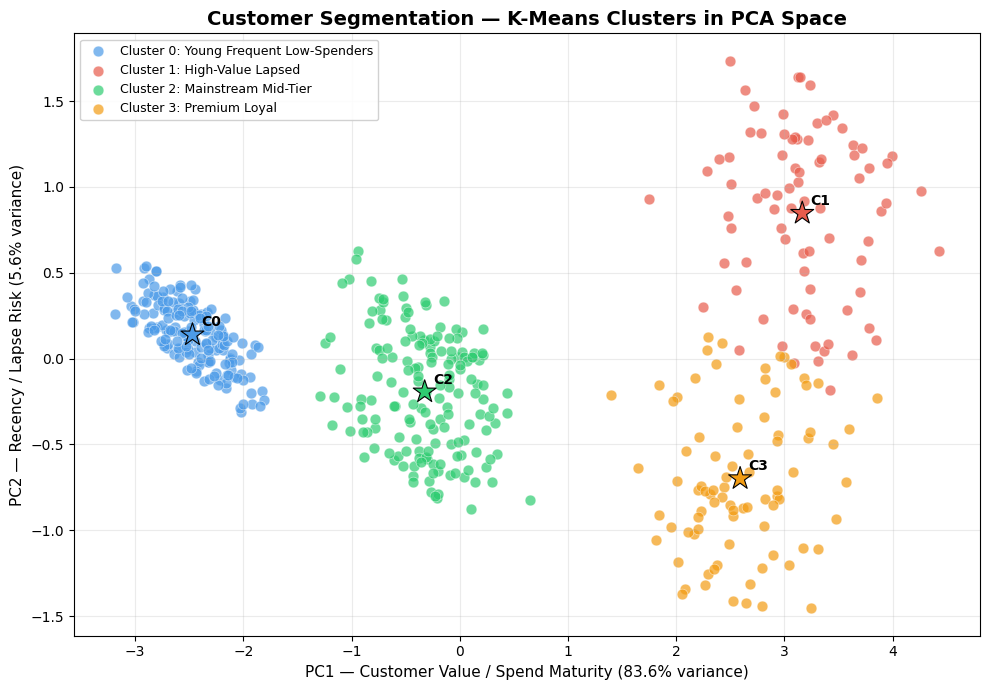

Total variance explained in this 2D plot: 89.1%


In [10]:
palette = ['#4C9BE8', '#E85C4C', '#2ECC71', '#F39C12']
cluster_names = {
    0: 'Cluster 0: Young Frequent Low-Spenders',
    1: 'Cluster 1: High-Value Lapsed',
    2: 'Cluster 2: Mainstream Mid-Tier',
    3: 'Cluster 3: Premium Loyal',
}

fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id, color in enumerate(palette):
    mask = df['cluster'] == cluster_id
    ax.scatter(
        df.loc[mask, 'PC1'],
        df.loc[mask, 'PC2'],
        c=color, label=cluster_names[cluster_id],
        alpha=0.7, edgecolors='white', linewidths=0.4, s=60
    )

# Plot centroids in PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c=palette, marker='*', s=300,
    edgecolors='black', linewidths=0.8, zorder=10,
    label='_nolegend_'
)
for i, (cx, cy) in enumerate(centroids_pca):
    ax.annotate(f'C{i}', (cx, cy), textcoords='offset points',
                xytext=(6, 6), fontsize=10, fontweight='bold')

ax.set_title('Customer Segmentation — K-Means Clusters in PCA Space',
             fontsize=14, fontweight='bold')
ax.set_xlabel('PC1 — Customer Value / Spend Maturity (83.6% variance)', fontsize=11)
ax.set_ylabel('PC2 — Recency / Lapse Risk (5.6% variance)', fontsize=11)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('plot_pca_clusters.png', dpi=120)
plt.show()

print(f"Total variance explained in this 2D plot: {pca.explained_variance_ratio_.sum()*100:.1f}%")